In [1]:
pip install emoji vncorenlp

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 85.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 51.1 MB/s eta 0:00:00
  Created wheel for vncorenlp: filename=vncorenlp-1.0.3-py3-none-any.whl size=2645933 sha256=fd50b2d9b3176ee7d25ef762a0b7a20c1b3a2ada2ed293e42a236f5bae551568
  Stored in directory: /root/.cache/pip/wheels/6f/19/20/ec7083125fd06db1a19d0d3ca18806ecf4e8ed1464713b4efa
Successfully built vncorenlp


In [2]:
import html
import inspect
import random
import re
import unicodedata
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, Sequence
from urllib.request import urlretrieve

import emoji
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from sklearn.metrics import classification_report
from torch import nn
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from vncorenlp import VnCoreNLP


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Config

In [4]:
run_name = "vlsp-2018-restaurant-e5-small"
train_csv_path = Path("/content/drive/MyDrive/bachnt/KHDL/vlsp2018_restaurant/1-VLSP2018-SA-Restaurant-train.csv")
val_csv_path = Path("/content/drive/MyDrive/bachnt/KHDL/vlsp2018_restaurant/2-VLSP2018-SA-Restaurant-dev.csv")
test_csv_path = Path("/content/drive/MyDrive/bachnt/KHDL/vlsp2018_restaurant/3-VLSP2018-SA-Restaurant-test.csv")
pretrained_model_name = "intfloat/multilingual-e5-small"


In [5]:
epochs = 20
batch_size = 21
max_length = 256
learning_rate = 2e-4
weight_decay = 0.0
warmup_ratio = 0.1
early_stopping_patience = 7
early_stopping_min_delta = 0.0
num_workers = 0
multi_branch = False
use_text_preprocessing = True
seed = 42

output_dir = Path("/content/drive/MyDrive/bachnt/KHDL/checkpoints")
prediction_dir = Path("/content/drive/MyDrive/bachnt/KHDL/predictions")


# Preprocess

## Label Mapping


In [6]:
class PolarityMapping:
    INDEX_TO_POLARITY = {0: None, 1: "positive", 2: "negative", 3: "neutral"}
    POLARITY_TO_INDEX = {None: 0, "positive": 1, "negative": 2, "neutral": 3}


##  Word Segmentation


In [7]:
VNCORENLP_BASE_URL = "https://raw.githubusercontent.com/vncorenlp/VnCoreNLP/master"
VNCORENLP_FILES = [
    "VnCoreNLP-1.2.jar",
    "models/wordsegmenter/vi-vocab",
    "models/wordsegmenter/wordsegmenter.rdr",
]
WORD_SEGMENTER: VnCoreNLP | None = None


def ensure_vncorenlp(vncorenlp_dir: str | Path = "VnCoreNLP") -> Path:
    vncorenlp_dir = Path(vncorenlp_dir)
    for relative_path in VNCORENLP_FILES:
        local_path = vncorenlp_dir / relative_path
        if local_path.exists():
            continue
        local_path.parent.mkdir(parents=True, exist_ok=True)
        url = f"{VNCORENLP_BASE_URL}/{relative_path}"
        print(f"Downloading {url} -> {local_path}")
        urlretrieve(url, local_path)
    return vncorenlp_dir


def get_word_segmenter() -> VnCoreNLP:
    global WORD_SEGMENTER
    if WORD_SEGMENTER is None:
        vncorenlp_dir = ensure_vncorenlp()
        WORD_SEGMENTER = VnCoreNLP(
            str(vncorenlp_dir / "VnCoreNLP-1.2.jar"),
            annotators="wseg",
            quiet=True,
        )
    return WORD_SEGMENTER


## Text Cleaning


In [8]:
TEENCODE_URL = "https://raw.githubusercontent.com/NeoCyber05/Aspect_Based_Sentiment_Analysis_for_Place_Reviews/main/training/teencode/res_teencode.txt"
ACRONYM_MAP: dict[str, str] | None = None


def build_acronym_map(teencode_path: str | Path = "teencode.txt") -> dict[str, str]:
    teencode_path = Path(teencode_path)
    print(f"Downloading {TEENCODE_URL} -> {teencode_path}")
    urlretrieve(TEENCODE_URL, teencode_path)
    mapping: dict[str, str] = {}
    for line in teencode_path.read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line:
            continue
        if "	" in line:
            teencode, normalized = line.split("	", 1)
        elif " - " in line:
            teencode, normalized = line.split(" - ", 1)
        else:
            continue
        teencode = teencode.strip().lower()
        normalized = normalized.strip()
        if teencode and normalized:
            mapping[teencode] = normalized
    return mapping
def normalize_acronyms(text: str) -> str:
    global ACRONYM_MAP
    if ACRONYM_MAP is None:
        ACRONYM_MAP = build_acronym_map()
    return " ".join(ACRONYM_MAP.get(word.lower(), word) for word in text.split())


def remove_HTML(text: str) -> str:
    text = html.unescape(str(text))
    return re.sub(r"<[^>]+>", " ", text)


def convert_unicode(text: str) -> str:
    return unicodedata.normalize("NFC", text)


def word_segmentation(text: str) -> str:
    sentences = get_word_segmenter().tokenize(text)
    return " ".join(token for sentence in sentences for token in sentence)


def remove_unnecessary_characters(text: str) -> str:
    text = emoji.replace_emoji(text, " ")
    text = re.sub(r"[^\w\s]", " ", text, flags=re.UNICODE)
    return re.sub(r"\s+", " ", text).strip()


def text_preprocess(text: str) -> str:
    text = remove_HTML(text)
    text = convert_unicode(text)
    text = normalize_acronyms(text)
    text = word_segmentation(text)
    return remove_unnecessary_characters(text)


# Dataset


In [9]:
def infer_aspect_category_names(csv_path: str | Path) -> list[str]:
    columns = pd.read_csv(csv_path, nrows=0).columns.tolist()
    return [column for column in columns if column != "Review"]


class ABSACsvDataset(Dataset):
    def __init__(
        self,
        csv_path: str | Path,
        aspect_category_names: Sequence[str] | None = None,
        text_preprocessor=None,
    ) -> None:
        self.csv_path = Path(csv_path)
        self.frame = pd.read_csv(self.csv_path)
        self.aspect_category_names = list(aspect_category_names or infer_aspect_category_names(self.csv_path))
        self.raw_texts = self.frame["Review"].astype(str).tolist()
        if text_preprocessor is None:
            self.texts = self.raw_texts
        else:
            self.texts = [
                text_preprocessor(text)
                for text in tqdm(self.raw_texts, desc=f"preprocess {self.csv_path.name}", leave=False)
            ]
        self.labels = self.frame[self.aspect_category_names].fillna(0).astype("int64").to_numpy()

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, index: int) -> dict[str, object]:
        return {"text": self.texts[index], "labels": self.labels[index]}


## Collator And Dataloaders


In [10]:
@dataclass
class ABSACollator:
    tokenizer: object
    max_length: int = 256

    def __call__(self, examples: list[dict[str, object]]) -> dict[str, torch.Tensor]:
        texts = [str(example["text"]) for example in examples]
        labels = torch.tensor(np.stack([example["labels"] for example in examples]), dtype=torch.long)
        encoded = self.tokenizer(
            texts,
            max_length=self.max_length,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        encoded["labels"] = labels
        return encoded


def build_dataloaders(
    train_csv_path: str | Path,
    val_csv_path: str | Path,
    test_csv_path: str | Path,
    tokenizer: object,
    batch_size: int = 8,
    max_length: int = 256,
    num_workers: int = 0,
    text_preprocessor=None,
) -> tuple[dict[str, DataLoader], list[str]]:
    paths = {
        "train": Path(train_csv_path),
        "val": Path(val_csv_path),
        "test": Path(test_csv_path),
    }
    aspect_category_names = infer_aspect_category_names(paths["train"])
    collator = ABSACollator(tokenizer=tokenizer, max_length=max_length)
    datasets = {
        split: ABSACsvDataset(
            path,
            aspect_category_names=aspect_category_names,
            text_preprocessor=text_preprocessor,
        )
        for split, path in paths.items()
    }
    loaders = {
        "train": DataLoader(datasets["train"], batch_size=batch_size, shuffle=True, num_workers=num_workers, collate_fn=collator),
        "val": DataLoader(datasets["val"], batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collator),
        "test": DataLoader(datasets["test"], batch_size=batch_size, shuffle=False, num_workers=num_workers, collate_fn=collator),
    }
    return loaders, aspect_category_names


# Model

In [11]:
class TransformerABSA(nn.Module):
    def __init__(
        self,
        pretrained_model_name: str,
        aspect_category_names: Iterable[str],
        multi_branch: bool = False,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()
        self.aspect_category_names = list(aspect_category_names)
        self.multi_branch = multi_branch
        self.transformer = AutoModel.from_pretrained(pretrained_model_name)
        hidden_size = self.transformer.config.hidden_size
        self.dropout = nn.Dropout(dropout)
        self.classifier_heads = nn.ModuleList([nn.Linear(hidden_size, 4) for _ in self.aspect_category_names])
        self._transformer_forward_args = set(inspect.signature(self.transformer.forward).parameters)

    def forward(
        self,
        input_ids: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
        token_type_ids: torch.Tensor | None = None,
    ) -> torch.Tensor:
        model_inputs = {"input_ids": input_ids}
        if attention_mask is not None:
            model_inputs["attention_mask"] = attention_mask
        if token_type_ids is not None and "token_type_ids" in self._transformer_forward_args:
            model_inputs["token_type_ids"] = token_type_ids

        outputs = self.transformer(**model_inputs)
        token_embeddings = outputs.last_hidden_state
        if attention_mask is None:
            pooled_output = token_embeddings.mean(dim=1)
        else:
            mask = attention_mask.unsqueeze(-1).type_as(token_embeddings)
            pooled_output = (token_embeddings * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-9)
        review_embedding = self.dropout(pooled_output)
        logits_by_aspect = torch.stack([head(review_embedding) for head in self.classifier_heads], dim=1)
        if self.multi_branch:
            return logits_by_aspect
        return logits_by_aspect.reshape(logits_by_aspect.size(0), -1)

    def reshape_logits(self, logits: torch.Tensor) -> torch.Tensor:
        if logits.dim() == 3:
            return logits
        return logits.reshape(logits.size(0), len(self.aspect_category_names), 4)

    @torch.no_grad()
    def acsa_predict(self, batch: dict[str, torch.Tensor]) -> torch.Tensor:
        self.eval()
        logits = self(**batch)
        logits = self.reshape_logits(logits)
        return logits.argmax(dim=-1)

    def print_acsa_pred(self, y_pred: torch.Tensor) -> None:
        if y_pred.dim() > 1:
            y_pred = y_pred[0]
        for aspect_category, label_index in zip(self.aspect_category_names, y_pred.tolist()):
            polarity = PolarityMapping.INDEX_TO_POLARITY[int(label_index)]
            if polarity:
                print(f"=> {aspect_category},{polarity}")

# Eval

In [12]:
class ABSASklearnEvaluator:
    def __init__(self, y_test, y_pred, aspect_category_names):
        y_test = np.asarray(y_test)
        y_pred = np.asarray(y_pred)
        aspect_test, aspect_pred = [], []
        aspect_polarity_test, aspect_polarity_pred = [], []

        for row_test, row_pred in zip(y_test, y_pred):
            for index, (col_test, col_pred) in enumerate(zip(row_test, row_pred)):
                aspect_name = aspect_category_names[index]
                aspect_test.append(bool(col_test) * aspect_name)
                aspect_pred.append(bool(col_pred) * aspect_name)
                aspect_polarity_test.append(f"{aspect_name},{PolarityMapping.INDEX_TO_POLARITY[int(col_test)]}")
                aspect_polarity_pred.append(f"{aspect_name},{PolarityMapping.INDEX_TO_POLARITY[int(col_pred)]}")

        self.aspect_category_report = classification_report(
            aspect_test,
            aspect_pred,
            digits=4,
            zero_division=1,
            output_dict=True,
        )
        self.aspect_category_polarity_report = classification_report(
            aspect_polarity_test,
            aspect_polarity_pred,
            digits=4,
            zero_division=1,
            output_dict=True,
        )

    def report(self, report_type: str):
        if report_type == "aspect#category":
            return pd.DataFrame(self.aspect_category_report).T
        if report_type == "aspect#category,polarity":
            return pd.DataFrame(self.aspect_category_polarity_report).T
        raise ValueError('report_type must be "aspect#category" or "aspect#category,polarity"')


# Training

In [13]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def move_batch_to_device(batch: dict[str, torch.Tensor], device: torch.device) -> dict[str, torch.Tensor]:
    return {key: value.to(device) for key, value in batch.items()}


def model_inputs(batch: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:
    allowed = {"input_ids", "attention_mask", "token_type_ids"}
    return {key: value for key, value in batch.items() if key in allowed}


def compute_loss(model: TransformerABSA, criterion: nn.Module, batch: dict[str, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor]:
    labels = batch["labels"]
    logits = model(**model_inputs(batch))
    logits_by_aspect = model.reshape_logits(logits)
    loss = criterion(logits_by_aspect.reshape(-1, 4), labels.reshape(-1))
    return loss, logits_by_aspect


def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device: torch.device) -> float:
    model.train()
    total_loss = 0.0
    for batch in tqdm(dataloader, desc="train", leave=False):
        batch = move_batch_to_device(batch, device)
        optimizer.zero_grad(set_to_none=True)
        loss, _ = compute_loss(model, criterion, batch)
        loss.backward()
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / max(1, len(dataloader))


@torch.no_grad()
def evaluate(model, dataloader, criterion, device: torch.device) -> dict[str, float]:
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for batch in tqdm(dataloader, desc="eval", leave=False):
        batch = move_batch_to_device(batch, device)
        loss, logits = compute_loss(model, criterion, batch)
        predictions = logits.argmax(dim=-1)
        labels = batch["labels"]
        total_loss += loss.item()
        correct += (predictions == labels).sum().item()
        total += labels.numel()
    return {"loss": total_loss / max(1, len(dataloader)), "accuracy": correct / max(1, total)}


def save_checkpoint(path: Path, model: TransformerABSA, optimizer: torch.optim.Optimizer, epoch: int, metrics: dict[str, float]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(
        {
            "epoch": epoch,
            "metrics": metrics,
            "pretrained_model_name": pretrained_model_name,
            "aspect_category_names": model.aspect_category_names,
            "multi_branch": model.multi_branch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        },
        path,
    )


def plot_training_history(history: dict[str, list[float]], figsize=(15, 5)) -> None:
    plt.figure(figsize=figsize)
    plt.plot(history["loss"], linestyle="solid", marker="o", color="crimson", label="Train")
    if "val_loss" in history:
        plt.plot(history["val_loss"], linestyle="solid", marker="o", color="dodgerblue", label="Validation")
    plt.xlabel("Epochs", fontsize=14)
    plt.ylabel("Loss", fontsize=14)
    plt.title("Loss", fontsize=15)
    plt.legend(loc="best")
    plt.show()


def save_absa_predictions(save_path: str | Path, raw_texts, encoded_review_labels, aspect_category_names) -> None:
    save_path = Path(save_path)
    save_path.parent.mkdir(parents=True, exist_ok=True)
    with save_path.open("w", encoding="utf-8") as file:
        for index, encoded_label in tqdm(list(enumerate(encoded_review_labels)), desc="write predictions"):
            polarities = [PolarityMapping.INDEX_TO_POLARITY[int(label)] for label in encoded_label]
            annotation_text = ", ".join(
                f"{{{aspect_category}, {polarity}}}"
                for aspect_category, polarity in zip(aspect_category_names, polarities)
                if polarity
            )
            file.write(f"#{index + 1}\n{raw_texts[index]}\n{annotation_text}\n\n")


In [14]:
set_seed(seed)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

csv_paths = {
    "train": Path(train_csv_path),
    "val": Path(val_csv_path),
    "test": Path(test_csv_path),
}
missing_paths = [path for path in csv_paths.values() if not path.exists()]
if missing_paths:
    raise FileNotFoundError(
        "Missing CSV files. Change train_csv_path, val_csv_path, or test_csv_path.\n"
        + "\n".join(str(path) for path in missing_paths)
    )

for split, path in csv_paths.items():
    print(f"{split}: {path}")

pd.read_csv(csv_paths["train"], nrows=3)

Device: cuda
train: /content/drive/MyDrive/bachnt/KHDL/vlsp2018_restaurant/1-VLSP2018-SA-Restaurant-train.csv
val: /content/drive/MyDrive/bachnt/KHDL/vlsp2018_restaurant/2-VLSP2018-SA-Restaurant-dev.csv
test: /content/drive/MyDrive/bachnt/KHDL/vlsp2018_restaurant/3-VLSP2018-SA-Restaurant-test.csv


,Review,AMBIENCE#GENERAL,DRINKS#PRICES,DRINKS#QUALITY,DRINKS#STYLE&OPTIONS,FOOD#PRICES,FOOD#QUALITY,FOOD#STYLE&OPTIONS,LOCATION#GENERAL,RESTAURANT#GENERAL,RESTAURANT#MISCELLANEOUS,RESTAURANT#PRICES,SERVICE#GENERAL
0,"_ Ảnh chụp từ hôm qua, đi chơi với gia đình và...",0,0,0,0,0,3,3,0,0,0,0,0
1,"_Hương vị thơm ngon, ăn cay cay rất thích, nêm...",1,0,0,0,3,1,1,0,1,0,3,2
2,- 1 bàn tiệc hoành tráng 3 đứa ăn no muốn tắt ...,2,0,0,0,1,1,1,2,1,1,0,1


In [15]:
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name)

def preprocess_for_model(text: str) -> str:
    return text_preprocess(text)

active_text_preprocessor = preprocess_for_model if use_text_preprocessing else None
print(f"Text preprocessing: {'enabled' if active_text_preprocessor else 'disabled'}")

loaders, aspect_category_names = build_dataloaders(
    train_csv_path=train_csv_path,
    val_csv_path=val_csv_path,
    test_csv_path=test_csv_path,
    tokenizer=tokenizer,
    batch_size=batch_size,
    max_length=max_length,
    num_workers=num_workers,
    text_preprocessor=active_text_preprocessor,
)

print(f"Aspects: {len(aspect_category_names)}")
print(aspect_category_names)
print({split: len(loader.dataset) for split, loader in loaders.items()})
print("Raw sample:", loaders["train"].dataset.raw_texts[0][:250])
print("Model input sample:", loaders["train"].dataset.texts[0][:250])



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

Text preprocessing: enabled


preprocess 1-VLSP2018-SA-Restaurant-train.csv:   0%|          | 0/2961 [00:00<?, ?it/s]

preprocess 2-VLSP2018-SA-Restaurant-dev.csv:   0%|          | 0/1290 [00:00<?, ?it/s]

preprocess 3-VLSP2018-SA-Restaurant-test.csv:   0%|          | 0/500 [00:00<?, ?it/s]

Aspects: 12
['AMBIENCE#GENERAL', 'DRINKS#PRICES', 'DRINKS#QUALITY', 'DRINKS#STYLE&OPTIONS', 'FOOD#PRICES', 'FOOD#QUALITY', 'FOOD#STYLE&OPTIONS', 'LOCATION#GENERAL', 'RESTAURANT#GENERAL', 'RESTAURANT#MISCELLANEOUS', 'RESTAURANT#PRICES', 'SERVICE#GENERAL']
{'train': 2961, 'val': 1290, 'test': 500}
Raw sample: _ Ảnh chụp từ hôm qua, đi chơi với gia đình và 1 nhà họ hàng đang sống tại Sài Gòn. _ Hôm qua đi ăn trưa muộn, ai cũng đói hết nên lúc có đồ ăn là nhào vô ăn liền, bởi vậy mới quên chụp các phần gọi thêm với nước mắm, chỉ chụp món chính thôi! _ Đói q
Model input sample: _ Ảnh chụp từ hôm_qua đi chơi với gia_đình và 1 nhà họ_hàng đang sống tại Sài_Gòn _ Hôm_qua đi ăn trưa muộn ai cũng đói hết nên lúc có đồ_ăn là nhào vô ăn_liền bởi_vậy mới quên chụp các phần gọi thêm với nước_mắm chỉ chụp món chính thôi _ Đói quá nên


In [16]:
model = TransformerABSA(
    pretrained_model_name=pretrained_model_name,
    aspect_category_names=aspect_category_names,
    multi_branch=multi_branch,
).to(device)

optimizer = AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
criterion = nn.CrossEntropyLoss()

total_steps = len(loaders["train"]) * epochs
warmup_steps = int(total_steps * warmup_ratio)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total train steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")

model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: intfloat/multilingual-e5-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total train steps: 2820
Warmup steps: 282


In [17]:
history = {"loss": [], "val_loss": [], "val_accuracy": []}
best_val_loss = float("inf")
epochs_without_improvement = 0

best_checkpoint_path = output_dir / f"{run_name}-best.pt"
last_checkpoint_path = output_dir / f"{run_name}-last.pt"

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, loaders["train"], optimizer, scheduler, criterion, device)
    val_metrics = evaluate(model, loaders["val"], criterion, device)

    history["loss"].append(train_loss)
    history["val_loss"].append(val_metrics["loss"])
    history["val_accuracy"].append(val_metrics["accuracy"])

    print(
        f"epoch={epoch} "
        f"train_loss={train_loss:.4f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_accuracy={val_metrics['accuracy']:.4f}"
    )

    save_checkpoint(last_checkpoint_path, model, optimizer, epoch, val_metrics)
    if val_metrics["loss"] < best_val_loss - early_stopping_min_delta:
        best_val_loss = val_metrics["loss"]
        epochs_without_improvement = 0
        save_checkpoint(best_checkpoint_path, model, optimizer, epoch, val_metrics)
        print(f"Saved best checkpoint: {best_checkpoint_path}")
    else:
        epochs_without_improvement += 1
        print(
            f"No val_loss improvement for "
            f"{epochs_without_improvement}/{early_stopping_patience} epochs"
        )
        if epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch}. Best val_loss={best_val_loss:.4f}")
            break

pd.DataFrame(history)

train:   0%|          | 0/141 [00:00<?, ?it/s]

eval:   0%|          | 0/62 [00:00<?, ?it/s]

epoch=1 train_loss=0.9591 val_loss=0.6444 val_accuracy=0.8306
Saved best checkpoint: /content/drive/MyDrive/bachnt/KHDL/checkpoints/vlsp-2018-restaurant-e5-small-best.pt


train:   0%|          | 0/141 [00:00<?, ?it/s]

eval:   0%|          | 0/62 [00:00<?, ?it/s]

...

epoch=19 train_loss=0.3181 val_loss=0.3718 val_accuracy=0.8729
No val_loss improvement for 5/7 epochs


train:   0%|          | 0/141 [00:00<?, ?it/s]

eval:   0%|          | 0/62 [00:00<?, ?it/s]

epoch=20 train_loss=0.3138 val_loss=0.3680 val_accuracy=0.8747
Saved best checkpoint: /content/drive/MyDrive/bachnt/KHDL/checkpoints/vlsp-2018-restaurant-e5-small-best.pt


,loss,val_loss,val_accuracy
0,0.959098,0.644352,0.830556
1,0.585560,0.469787,0.841731
2,0.494973,0.423360,0.861886
3,0.460616,0.394611,0.877390
4,0.438639,0.390512,0.876034
5,0.427892,0.437789,0.852907
6,0.498923,0.437692,0.854845
7,0.474652,0.416225,0.865956
8,0.480406,0.429780,0.850581
9,0.443419,0.394446,0.872610


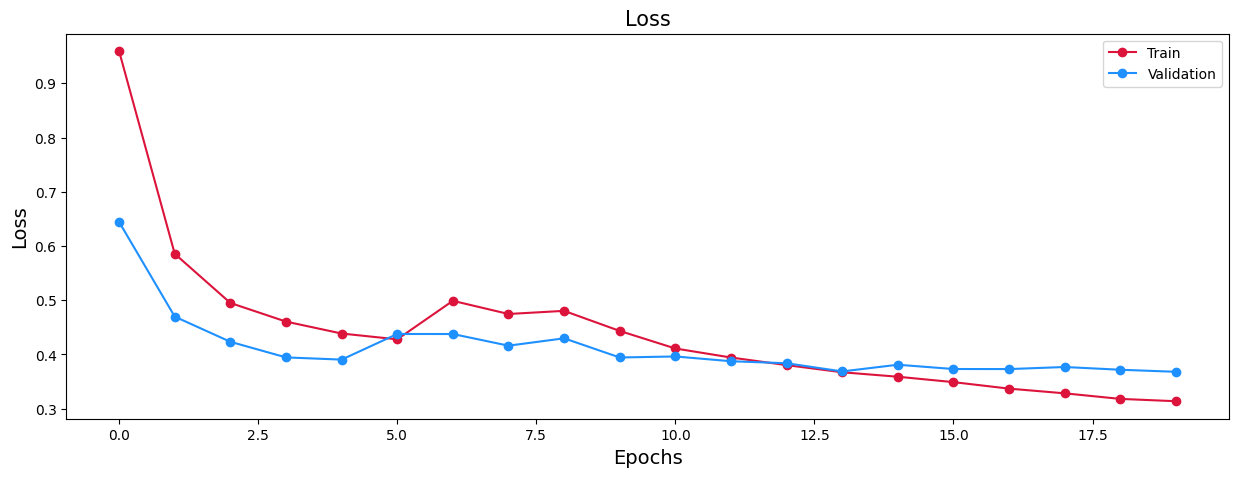

In [18]:
plot_training_history(history)

In [19]:
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)

test_metrics = evaluate(model, loaders["test"], criterion, device)
test_metrics

eval:   0%|          | 0/24 [00:00<?, ?it/s]

{'loss': 0.7007860913872719, 'accuracy': 0.747}

In [20]:
@torch.no_grad()
def predict_dataloader(model: TransformerABSA, dataloader, device: torch.device) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_labels = []
    all_predictions = []
    for batch in tqdm(dataloader, desc="predict", leave=False):
        batch = move_batch_to_device(batch, device)
        logits = model(**model_inputs(batch))
        logits = model.reshape_logits(logits)
        predictions = logits.argmax(dim=-1)
        all_labels.append(batch["labels"].detach().cpu().numpy())
        all_predictions.append(predictions.detach().cpu().numpy())
    return np.concatenate(all_labels, axis=0), np.concatenate(all_predictions, axis=0)


y_test, y_pred = predict_dataloader(model, loaders["test"], device)
evaluator = ABSASklearnEvaluator(y_test, y_pred, aspect_category_names)
evaluator.report("aspect#category")

predict:   0%|          | 0/24 [00:00<?, ?it/s]

,precision,recall,f1-score,support
,0.807683,0.886624,0.845314,3581.000000
AMBIENCE#GENERAL,0.769547,0.733333,0.751004,255.000000
DRINKS#PRICES,1.000000,0.013158,0.025974,76.000000
DRINKS#QUALITY,1.000000,0.000000,0.000000,71.000000
DRINKS#STYLE&OPTIONS,1.000000,0.000000,0.000000,46.000000
FOOD#PRICES,0.814815,0.930514,0.868829,331.000000
FOOD#QUALITY,0.934599,0.969365,0.951665,457.000000
FOOD#STYLE&OPTIONS,0.888350,0.908189,0.898160,403.000000
LOCATION#GENERAL,0.785185,0.592179,0.675159,179.000000
RESTAURANT#GENERAL,0.523605,0.547085,0.535088,223.000000


In [21]:
evaluator.report("aspect#category,polarity")


,precision,recall,f1-score,support
"AMBIENCE#GENERAL,None",0.735409,0.771429,0.752988,245.000
"AMBIENCE#GENERAL,negative",1.000000,0.000000,0.000000,26.000
"AMBIENCE#GENERAL,neutral",0.277778,0.104167,0.151515,48.000
"AMBIENCE#GENERAL,positive",0.626667,0.779006,0.694581,181.000
"DRINKS#PRICES,None",0.849699,1.000000,0.918743,424.000
"DRINKS#PRICES,negative",1.000000,0.000000,0.000000,3.000
"DRINKS#PRICES,neutral",1.000000,0.022222,0.043478,45.000
"DRINKS#PRICES,positive",1.000000,0.000000,0.000000,28.000
"DRINKS#QUALITY,None",0.858000,1.000000,0.923574,429.000
"DRINKS#QUALITY,negative",1.000000,0.000000,0.000000,6.000


In [22]:
prediction_path = prediction_dir / f"{run_name}-notebook.txt"
save_absa_predictions(
    save_path=prediction_path,
    raw_texts=loaders["test"].dataset.raw_texts,
    encoded_review_labels=y_pred,
    aspect_category_names=aspect_category_names,
)
print(f"Saved predictions: {prediction_path}")


write predictions:   0%|          | 0/500 [00:00<?, ?it/s]

Saved predictions: /content/drive/MyDrive/bachnt/KHDL/predictions/vlsp-2018-restaurant-e5-small-notebook.txt


In [23]:
@torch.no_grad()
def predict_texts(texts: str | list[str]) -> np.ndarray:
    if isinstance(texts, str):
        texts = [texts]
    model_texts = [active_text_preprocessor(text) for text in texts] if active_text_preprocessor else texts
    encoded = tokenizer(
        model_texts,
        max_length=max_length,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )
    encoded = {key: value.to(device) for key, value in encoded.items()}
    logits = model(**encoded)
    logits = model.reshape_logits(logits)
    return logits.argmax(dim=-1).detach().cpu().numpy()


sample_predictions = predict_texts(["Vịt quay và dimsum tại nhà hàng rất ngon, mình lần nào tới ăn cũng gọi vị vừa rẻ lại vừa ngon. Nếu các bạn tới có thể gọi set A là có cả 2 món ngon này luôn nhé. Nhân viên rất là nhanh nhẹn, ko phải chờ đợi lâu. Ngoài ra rau cải xào ở đây cũng rất ngon nhé."])
sample_predictions


array([[0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1]])

In [24]:
model.print_acsa_pred(torch.tensor(sample_predictions[0]))

=> FOOD#PRICES,positive
=> FOOD#QUALITY,positive
=> RESTAURANT#GENERAL,positive
=> SERVICE#GENERAL,positive
